# Spatial patterns of comments 
This notebook implements analysis regarding the distance between planning applications and their associated comments. 

In [1]:
import pandas as pd
import numpy as np
import math
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from collections import Counter

import geopandas as gpd
from shapely.geometry import Polygon

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks
from elastic_search_fncs import ElasticSearchFncs
import preprocessing_fncs as ppf

nlp_tasks = NLP_Tasks()
esf = ElasticSearchFncs()

cs = Comments(env="dev")
tp = Topics(env='dev')

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


### Read in the topic dataframe with comments and topic assignments 

In [2]:
tp_df = tp.read_all()
tp_df.head()

,id,comment_id,topic_number,probability,add_date
0,1,230384FUL_16,[],[],2025-10-21
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21
3,4,230384FUL_22,[47],[1.0],2025-10-21
4,5,230384FUL_15,[2],[1.0],2025-10-21


In [3]:
# Read in the .csv with the topic names and representations 

topic_names = pd.read_csv('../model_outputs/topic_model/bertopic_less_topics/object_topics.csv')
topic_names.head()

,Topic,Count,Name,Representation,MaximalMarginalRelevance,KeyBERTInspired,Representative_Docs,doc_1,doc_2,doc_3
0,-1,38355,-1_the_to_and_of,"['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['parking', 'space', 'traffic', 'road', 'impac...",['i object to this proposal on several grounds...,i object to this proposal on several grounds. ...,"firstly, i have been very concerned by the beh...",residents of are already surrounded on two sid...
1,0,14746,0_object_planning_application_following,"['object', 'planning', 'application', 'followi...","['object', 'planning', 'application', 'followi...","['objection', 'following', 'reasons', 'applica...",['i strongly object to this proposal for the f...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...
2,1,7481,1_trees_garden_green_space,"['trees', 'garden', 'green', 'space', 'of', 't...","['trees', 'garden', 'green', 'space', 'of', 't...","['garden', 'trees', 'greenery', 'tree', 'natur...","['there is no space for a garden.', 'this deve...",there is no space for a garden.,this development is also contrary to the londo...,loss of garden / green space :
3,2,7004,2_parking_traffic_car_already,"['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'car', 'traffic', 'bus', 'parked',...","['2. traffic and parking :', '4. parking', 'pa...",2. traffic and parking :,4. parking,parking :
4,3,6644,3_character_design_out_of,"['character', 'design', 'out', 'of', 'keeping'...","['character', 'design', 'out', 'of', 'keeping'...","['design', 'character', 'appearance', 'style',...","['out of keeping with character of area', 'the...",out of keeping with character of area,the proposal would be out of keeping with the ...,design and character


In [4]:
# 'junk' topics - those that don't provide useful information for th purpose of this analysis
bad_topics = {"bad":[-1,0,10,16,31,39,41,42,56,57,88,98]}

# topics that are similar enough to be grouped together
same_topics = {"garden space":[1,43],
               "parking":[2,7,47], 
               "out of character":[3,36,40], 
               "too tall":[5,33],
               "conservation area":[8,35,48],
               "noise pollution":[11,38,46,49],
               "overdevelopment":[13,25],
               "traffic congestion":[18, 21]}

In [5]:
# Build a reverse mapping from each old topic to representative topic
topic_map = {}
for _, nums in same_topics.items():
    main = nums[0]
    for n in nums:
        topic_map[n] = main

# Create new columns for updated topics and probabilities with empty lists
tp_df['topic_number_updated'] = [[] for _ in range(len(tp_df))]
tp_df['probability_updated'] = [[] for _ in range(len(tp_df))]

# Process each row to filter and merge topics
for i in range(len(tp_df)):
    topics = tp_df.at[i, 'topic_number']
    probs = tp_df.at[i, 'probability']

    # filter out topics >= 50
    filtered = [(t, p) for t, p in zip(topics, probs) if t < 50]

    # filter out topics in bad_topics
    filtered = [(t, p) for t, p in filtered if all(t not in v for v in bad_topics.values())]

    # merge topics in same_topics
    merged = {}
    for t, p in filtered:
        new_t = topic_map.get(t, t)  # replace with main topic if part of a group
        merged[new_t] = merged.get(new_t, 0) + p  # sum probabilities

    # store results
    tp_df.at[i, 'topic_number_updated'] = list(merged.keys())
    tp_df.at[i, 'probability_updated'] = list(merged.values())


### Read in the comments dataframe 

In [6]:
cs_df = cs.read_all()

# Merge updated topics back into comments dataframe
df = pd.merge(cs_df, tp_df[['comment_id', 'topic_number_updated', 'probability_updated']], on='comment_id', how='left')

In [7]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number_updated,probability_updated
0,88439,Barnet,23/4221/FUL_13,23/4221/FUL,45 Pine Grove Totteridge London N20 8LA,Objects,2023-11-08,I object to the proposed planning application ...,2025-04-10,51.632395,-0.194255,I object to the proposed planning application ...,E09000003,-0.244143,"[19, 1, 3]","[0.15161083219496335, 0.0915869136437463, 0.11..."
1,94013,Ealing,215737FUL_2,215737FUL,53 Gordon Road Ealing London W5 2AL W5 2AL,Objects,2021-10-30,I am writing as Chair of the GRASS (Gordon Roa...,2025-04-11,51.514611,-0.311787,I am writing as Chair of the GRASS ( and Surro...,E09000009,-0.232367,[],[]
2,106710,Ealing,230760FUL_6,230760FUL,19 Studley Grange Road Hanwell W7 2Lu W7 2Lu,Objects,2023-09-24,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",2025-05-01,51.503314,-0.336865,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",E09000009,-0.167873,[],[]
3,88908,Brent,20/0115_42,20/0115,"34 Gratton Terrace, London, NW2 6QE",Objects,2020-06-11,11/06/2020 - Further objection comment receive...,2025-04-10,51.560030,-0.218620,11/06/2020 - Further objection comment receive...,E09000003,-0.315872,[],[]
4,76007,Barnet,22/4044/FUL_2,22/4044/FUL,8 May's Lane Barnet EN5 2EE,Objects,2022-09-05,CONTINUED\nArticle 8 of the Human Rights Act s...,2025-04-08,51.645724,-0.203315,CONTINUED\nArticle 8 of the Human Rights Act s...,E09000003,-0.229557,"[9, 2, 1, 27, 19]","[1.0, 1.3250791908788773, 0.05583377844345686,..."


### Read in the dataframe of applications 

In [8]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

# drop 'Bromley' applications -  since I haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

application_df = ppf.format_df(application_df, 'borough')

There are 5850 applications in the dataset.
There are 5077 applications in the dataset after dropping Bromley applications.


In [9]:
application_df.head()

,lpa_app_no,valid_date,decision_date,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,street_name,site_name,site_number,polygon,wgs84_polygon,description
0,24/02204/FUL,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,Falmouth Street,NaN,"2, 10",GEOMETRYCOLLECTION (POLYGON ((538894.0 185094....,"polygon=linearring(x=[0.001716, 0.001703, 0.00...",Proposed mansard roof extension to the main bu...
1,25/0089,NaT,NaT,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,NaN,"92 Blenheim Gardens, London, NW2 4NT",NaN,NaN,NaN,Proposed change of use from HMO to a single dw...
2,24/1783,NaT,NaT,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,NaN,"1 - 6 The Drive, London, NW10 3UB",NaN,NaN,NaN,Demolition of existing buildings and garages a...
3,25/00205/PRECOU,NaT,NaT,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,Forest Lane,NaN,"176, 177",GEOMETRYCOLLECTION (POLYGON ((540475.0 185388....,"polygon=linearring(x=[0.024619, 0.024663, 0.02...",Prior Approval application for the change of u...
4,25/00181/PRECOU,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,Sprowston Mews,NaN,66,GEOMETRYCOLLECTION (POLYGON ((540218.0 185015....,"polygon=linearring(x=[0.020766, 0.020563, 0.02...",Prior Approval application for the change of u...


Get some additional information about the planning applications using the elastic search query 

In [10]:
esf = ElasticSearchFncs()
esf.check_connection()

Connected to Elastic Search


In [11]:
pld_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="01/05/2025")

In [12]:
# clean up the formatting of the pld_df
pld_df = ppf.format_df(pld_df)

# this function adds a 'housing_type' column to the pld_df - which summarises the housing type based on the number of units of each type
pld_df = ppf.add_housing_type(pld_df)

pld_df.head()

,lpa_name,uprn,actual_completion_date,decision,pp_id,postcode,wgs84_polygon.coordinates,wgs84_polygon.type,total_no_proposed_residential_units_shared_equity,total_no_proposed_residential_units_london_living_rent,...,total_no_affordable_units,polygon.crs.type,polygon.crs.properties.name,self_build,social_housing,affordable_rent,affordable_sale,market_rent,market_sale,housing_type
0,Hounslow,100023408264,NaT,Approved,13695286,TW8 9AG,"[[[-0.286869, 51.493028], [-0.28793, 51.494042...",Polygon,0,0,...,NaN,NaN,NaN,0,0,0,0,0,178,Market housing
1,Hounslow,100023490621,NaT,None,13685254,W4 2QA,"[[[-0.250017, 51.487899], [-0.249983, 51.48791...",Polygon,0,0,...,NaN,NaN,NaN,0,0,0,0,0,2,Market housing
2,Islington,5300030656,NaT,None,PP-13650297,None,"[[[-0.131906, 51.565624], [-0.131907, 51.56559...",Polygon,0,0,...,NaN,NaN,NaN,0,0,0,0,7,0,Market housing
3,Hounslow,None,NaT,None,13778763,None,"[[[-0.360138, 51.46925], [-0.359879, 51.468786...",Polygon,0,0,...,NaN,NaN,NaN,0,0,0,0,5,0,Market housing
4,Hounslow,100021513620,NaT,None,13653932,TW8 9PD,"[[[-0.307491, 51.491712], [-0.307491, 51.49170...",Polygon,0,0,...,NaN,NaN,NaN,2,0,0,0,0,0,Self-build housing


In [13]:
# create a unique identifier for each planning application by combining lpa_app_no and borough
pld_df['lpa_app_no_borough'] = pld_df['lpa_app_no'] + '_' + pld_df['borough']
df['lpa_app_no_borough'] = df['application_id'] + '_' + df['council']

In [14]:
# Merge additional information from pld_df into application_df and df
application_df = pd.merge(application_df, pld_df[['lpa_app_no', 'wgs84_polygon.coordinates']], left_on='lpa_app_no', right_on='lpa_app_no', how='left')
df = pd.merge(df, pld_df[['lpa_app_no_borough', 'housing_type', 'total_no_proposed_residential_units']], left_on='lpa_app_no_borough', right_on='lpa_app_no_borough', how='left')

In [15]:
# Select first element in list to get the Point object
application_df['geometry'] = application_df['wgs84_polygon.coordinates'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
application_df["geometry"] = application_df["geometry"].apply(lambda coords: Polygon(coords))

# Convert to GeoDataFrame
application_gdf = gpd.GeoDataFrame(application_df, geometry="geometry")

# Get centroids
application_gdf["centroid"] = application_gdf.geometry.centroid
# Get lat and lon columns
application_gdf["centroid_lon"] = application_gdf.centroid.x
application_gdf["centroid_lat"] = application_gdf.centroid.y

application_gdf.head()

,lpa_app_no,valid_date,decision_date,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,...,site_name,site_number,polygon,wgs84_polygon,description,wgs84_polygon.coordinates,geometry,centroid,centroid_lon,centroid_lat
0,24/02204/FUL,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,...,NaN,"2, 10",GEOMETRYCOLLECTION (POLYGON ((538894.0 185094....,"polygon=linearring(x=[0.001716, 0.001703, 0.00...",Proposed mansard roof extension to the main bu...,"[[[0.001716, 51.547651], [0.001703, 51.547679]...","POLYGON ((0.00172 51.54765, 0.0017 51.54768, 0...",POINT (0.00161 51.54774),0.001614,51.547740
1,25/0089,NaT,NaT,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,...,"92 Blenheim Gardens, London, NW2 4NT",NaN,NaN,NaN,Proposed change of use from HMO to a single dw...,NaN,POLYGON EMPTY,POINT EMPTY,NaN,NaN
2,24/1783,NaT,NaT,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,...,"1 - 6 The Drive, London, NW10 3UB",NaN,NaN,NaN,Demolition of existing buildings and garages a...,NaN,POLYGON EMPTY,POINT EMPTY,NaN,NaN
3,25/00205/PRECOU,NaT,NaT,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,...,NaN,"176, 177",GEOMETRYCOLLECTION (POLYGON ((540475.0 185388....,"polygon=linearring(x=[0.024619, 0.024663, 0.02...",Prior Approval application for the change of u...,"[[[0.024619, 51.549902], [0.024663, 51.549928]...","POLYGON ((0.02462 51.5499, 0.02466 51.54993, 0...",POINT (0.02445 51.55002),0.024447,51.550021
4,25/00181/PRECOU,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,...,NaN,66,GEOMETRYCOLLECTION (POLYGON ((540218.0 185015....,"polygon=linearring(x=[0.020766, 0.020563, 0.02...",Prior Approval application for the change of u...,"[[[0.020766, 51.546614], [0.020563, 51.546582]...","POLYGON ((0.02077 51.54661, 0.02056 51.54658, ...",POINT (0.02073 51.54652),0.020733,51.546520


In [16]:
# number and percent of nan values in centroid column   
nan_count = application_gdf['centroid_lon'].isna().sum()
total_count = len(application_gdf)
nan_percentage = (nan_count / total_count) * 100

print(f"Number of planning applications with missing centroid coordinates: {nan_count} ({nan_percentage:.2f}%)")

Number of planning applications with missing centroid coordinates: 1202 (22.98%)


In [17]:
# rows where centroid_lon is nan and site_name is nan 
nan_no_address = len(application_gdf[(application_gdf['centroid_lon'].isna()) & (application_gdf['site_name'].isna())])
nan_no_address_percentage = (nan_no_address / total_count) * 100
print(f"Number of planning applications with missing centroid coordinates and missing site name: {nan_no_address} ({nan_no_address_percentage:.2f}%)")

Number of planning applications with missing centroid coordinates and missing site name: 92 (1.76%)


NOTE: need to use Nominatum here to get the point co-ordinates for those applications where I'm missing the polygon, but I do have the text address. 

### Calculate the distance between the applications and comments (in km) 

In [18]:
# Uses Haversine formula to calculate distance between two lat/lon points

def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of the Earth in kilometers
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) ** 2 +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) ** 2)
    c = 2 * math.asin(math.sqrt(a))
    distance = R * c  # Distance in kilometers
    return distance

# Calculate the distance from each comment to the application
for i in range(len(df)):
    app_id = df.loc[i, 'application_id']
    lpa = df.loc[i, 'council']
    comment_lat = df.loc[i, 'lat']
    comment_lon = df.loc[i, 'lon']
    # find the corresponding application centroid
    app = application_gdf[(application_gdf['lpa_app_no'] == app_id) & (application_gdf['borough'] == lpa)]
    app_lat = app['centroid_lat'].values
    app_lon = app['centroid_lon'].values

    if len(app_lat) > 0 and len(app_lon) > 0 and not np.isnan(comment_lat) and not np.isnan(comment_lon):
        # calculate distance using Haversine formula
        distance = haversine_dist(comment_lat, comment_lon, app_lat[0], app_lon[0])
        df.loc[i, 'distance_to_application_km'] = distance
    else:
        df.loc[i, 'distance_to_application_km'] = np.nan

In [19]:
# summary statistics of distance to application
df['distance_to_application_km'].describe()

count    17925.000000
mean         1.508393
std          3.461546
min          0.000087
25%          0.078716
50%          0.270932
75%          0.896889
max         34.469806
Name: distance_to_application_km, dtype: float64

## Analysis of spatial distribution of comments 

Starting with distance decay of the number of comments by distance from the application. 

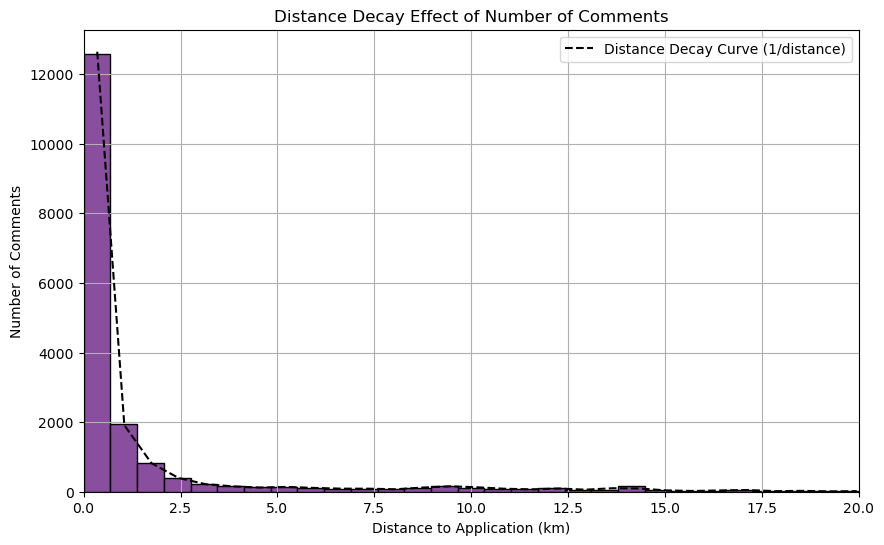

In [20]:
# plot histogram of distance to application

plt.figure(figsize=(10, 6))
plt.hist(df['distance_to_application_km'].dropna(), bins=50, color="#894e9e", edgecolor='black', alpha=1)
plt.xlim(0, 20)
plt.title('Histogram of comment distance to planning application')
plt.xlabel('Distance to application (km)')
plt.ylabel('Number of comments')

# overlay distance decay curve for comparison
max_distance = 20  # km
bin_size = 0.7  # km
bins = np.arange(0, max_distance + bin_size, bin_size)
counts, _ = np.histogram(df['distance_to_application_km'].dropna(), bins=bins)
bin_centers = bins[:-1] + bin_size / 2
plt.plot(bin_centers, counts, color='black', linestyle='--', label='Distance Decay Curve (1/distance)')
plt.title('Distance Decay Effect of Number of Comments')
plt.xlabel('Distance to Application (km)')
plt.ylabel('Number of Comments')

# # overlay with 1/x curve for comparison
# x = np.linspace(0.1, df['distance_to_application_km'].max(), 1000)
# y = 1000 / x  # scale factor to fit on histogram
# plt.plot(x, y, color='black', linestyle='--', label='1/x curve')

plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Percent of comments within 0.2km of the application
within_0_2km = df[df['distance_to_application_km'] <= 1]
percent_within_0_2km = (len(within_0_2km) / len(df)) * 100
print(f"Percent of comments within 0.2km of the application: {percent_within_0_2km:.2f}%")
print(f"Number of comments within 0.2km of the application: {len(within_0_2km)}")

Percent of comments within 0.2km of the application: 45.30%
Number of comments within 0.2km of the application: 13782


In [22]:
# summary statistics of distance to application by stance
df.groupby('stance')['distance_to_application_km'].describe()

,count,mean,std,min,25%,50%,75%,max
stance,,,,,,,,
Neutral,385.0,2.714499,5.069010,0.000560,0.080046,0.443840,2.443441,26.710091
Objects,16380.0,1.396486,3.313641,0.000087,0.076554,0.256497,0.825840,34.469806
Supports,1160.0,2.688292,4.423539,0.000214,0.145220,0.568138,3.005086,27.960136


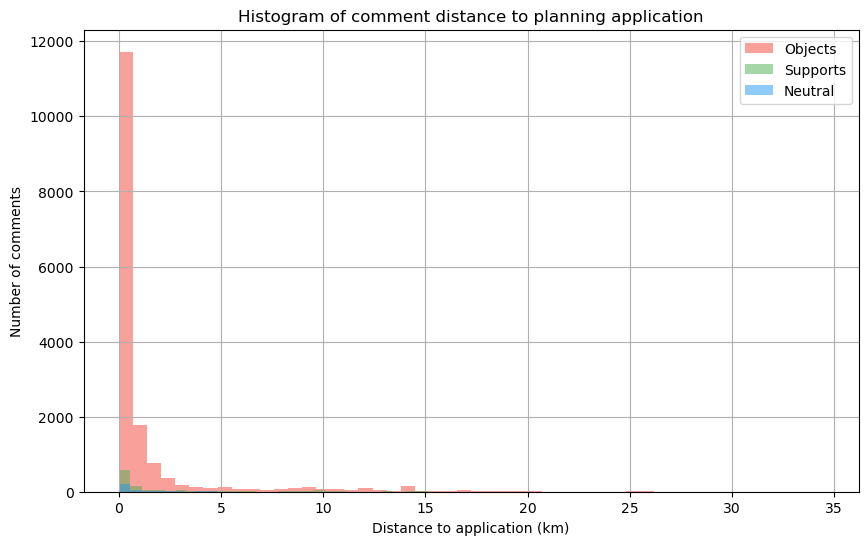

In [23]:
# histogram of distance to application by stance 

# specify colors for each stance
colors = {'Supports': '#4caf50', 'Objects': '#f44336', 'Neutral': '#2196f3'}

plt.figure(figsize=(10, 6))
stances = df['stance'].unique()
for stance in stances:
    subset = df[df['stance'] == stance]
    plt.hist(subset['distance_to_application_km'].dropna(), bins=50, alpha=0.5, label=stance, color=colors.get(stance, 'gray'))
plt.title('Histogram of comment distance to planning application')
plt.xlabel('Distance to application (km)')
plt.ylabel('Number of comments')
plt.legend()
plt.grid(True)
plt.show()

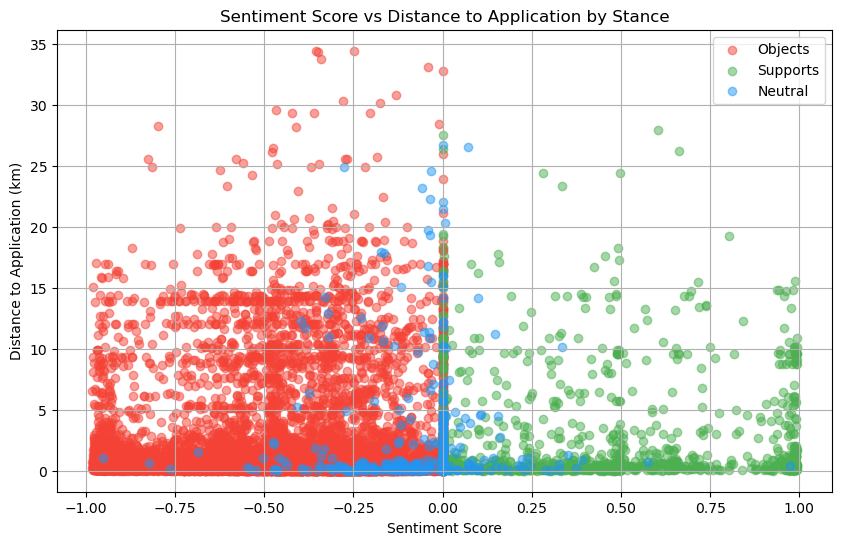

In [24]:
# scatter plot sentiment_score vs distance to application colour coded by stance
plt.figure(figsize=(10, 6))
stances = df['stance'].unique()
for stance in stances:
    subset = df[df['stance'] == stance]
    plt.scatter(subset['sentiment_score'], subset['distance_to_application_km'], alpha=0.5, label=stance, color=colors.get(stance, 'gray'))
plt.title('Sentiment Score vs Distance to Application by Stance')
plt.ylabel('Distance to Application (km)')
plt.xlabel('Sentiment Score')
plt.legend()
plt.grid(True)
plt.show()

### Variation in distance by topic

In [25]:
# make sure df['topic_number_updated'] is a list of integers
df['topic_number_updated'] = df['topic_number_updated'].apply(lambda x: [int(i) for i in x] if isinstance(x, list) else [])

In [26]:
# mean distance by topic
topic_distances = {}
for i in range(len(df)):
    topics = df.loc[i, 'topic_number_updated']
    distance = df.loc[i, 'distance_to_application_km']
    if not np.isnan(distance):
        for topic in topics:
            if topic not in topic_distances:
                topic_distances[topic] = []
            topic_distances[topic].append(distance)
for topic, distances in topic_distances.items():
    topic_distances[topic] = np.mean(distances) 
# convert to DataFrame for easier viewing
topic_distance_df = pd.DataFrame(list(topic_distances.items()), columns=['topic_number', 'mean_distance_km'])
topic_distance_df = topic_distance_df.sort_values(by='mean_distance_km')
topic_distance_df

,topic_number,mean_distance_km
0,19,1.052415
19,12,1.094272
24,23,1.162268
5,27,1.185052
7,6,1.224147
10,5,1.233526
28,44,1.273537
8,4,1.280296
12,20,1.302495
1,1,1.308523


In [27]:
# create dictionary mapping topic number to name
topic_dict = dict(zip(topic_names['Topic'], topic_names['Name']))

# reduce to only include topics present in the updated topic/comment dataframe
unique_topics = set()
for topics in tp_df['topic_number_updated']:
    unique_topics.update(topics)

filtered_topic_dict = {k: v for k, v in topic_dict.items() if k in unique_topics}

# remove number and underscores from topic names
for k in filtered_topic_dict:
    name = filtered_topic_dict[k]
    name = name.split('_', 1)[1] if '_' in name else name
    name = name.replace('_', ' ')
    filtered_topic_dict[k] = name

In [28]:
# Flatten topics and count frequencies in the topic/common dataframe
all_topics = [t for topics in tp_df['topic_number_updated'] for t in topics]
topic_counts = Counter(all_topics)

# Sort by frequency (descending)
topic_counts = dict(sorted(topic_counts.items(), key=lambda x: x[1], reverse=True))

In [29]:
x_label_map = {'parking traffic car already':'loss of parking',
 'trees garden green space':'loss of gardens',
 'character design out of':'out of character',
 'height scale buildings tall':'too tall',
 'noise disruption pollution will':'noise pollution',
 'light sunlight daylight loss':'loss of light',
 'density overdevelopment overcrowding dense':'overdevelopment',
 'amenity impact on of':'impact on amenities',
 'conservation heritage listed area':'heritage area',
 'family bedroom housing social':'wrong housing type',
 'privacy overlooking loss windows':'loss of privacy',
 'congested parking already traffic':'traffic congestion',
 'safety dangerous traffic fire':'unsafe',
 'bin refuse storage bins':'lack of bins',
 'height light privacy of':'too tall, loss of light',
 'environment wildlife biodiversity local': 'loss of wildlife',
 'water drainage flooding flood': 'flood risk',
 'view from the my': 'loss of view',
 'consultation engagement process been': 'insufficent community enagement',
 'impact parking on amenity': 'parking and amenity impact',
 'dust pollution air noise': 'air pollution',
 'business shop retail shops': 'impact on retail',
 'affordable housing homes rent': 'not affordable',
 'ugly eyesore visual an': 'eyesore',
 'disabled parking elderly accessible': 'lack of disabled parking',
 'parking character is traffic': 'parking and traffic',
 'carbon climate sustainable energy': 'not environmentally sustainable',
 'park green space trees': 'loss of parks',
 'value of community the': 'bad for community',
 'rent dwelling bed viability': 'rental properties'
}

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_21780/4175693113.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=x_labels, vert=True, flierprops=dict(marker='o', markersize=2, alpha=0.3), showmeans=True,


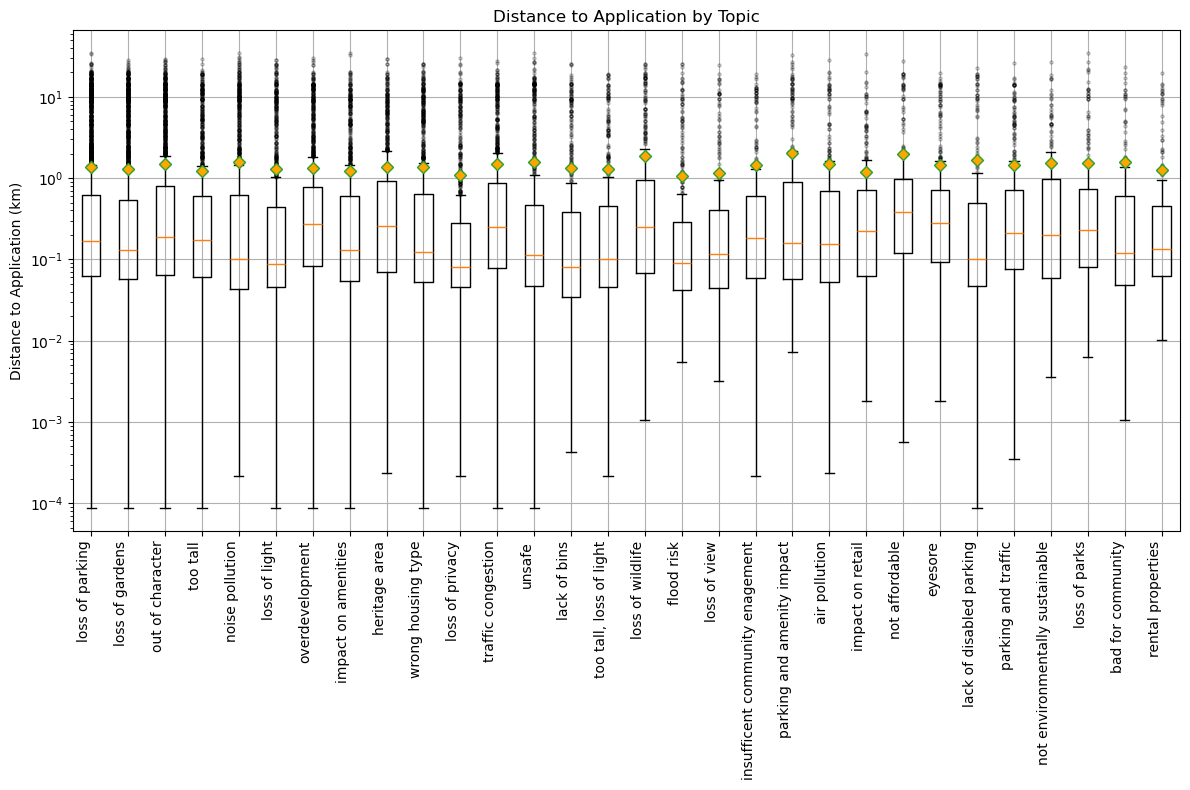

In [30]:
# boxplot of distance to application by topic using topic labels
plt.figure(figsize=(12, 8))
data_to_plot = []
x_labels = []
for topic, count in topic_counts.items():
    if topic in topic_distance_df['topic_number'].values:
        distances = df[df['topic_number_updated'].apply(lambda x: topic in x)]['distance_to_application_km'].dropna()
        if len(distances) > 0:
            data_to_plot.append(distances)
            topic_name = filtered_topic_dict.get(topic, f'Topic {topic}')
            # shorten topic name using x_label_map if available
            short_name = x_label_map.get(topic_name, topic_name)
            x_labels.append(f"{short_name}")
plt.boxplot(data_to_plot, labels=x_labels, vert=True, flierprops=dict(marker='o', markersize=2, alpha=0.3), showmeans=True,
            meanprops=dict(marker='D', markerfacecolor='orange'))
plt.yscale('log')
plt.xticks(rotation=90, ha='right')
plt.title('Distance to Application by Topic')
plt.ylabel('Distance to Application (km)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Variation in distance by housing types 

In [31]:
# summary statistics of distance to application by housing type
df.groupby('housing_type')['distance_to_application_km'].describe()

,count,mean,std,min,25%,50%,75%,max
housing_type,,,,,,,,
Market housing,12427.0,1.498629,3.485729,0.000087,0.062579,0.170256,0.848265,34.326519
Mixed affordable housing,3329.0,1.677131,3.693654,0.001562,0.228608,0.465846,1.096288,34.469806
Mixed social housing,1361.0,1.166176,2.221307,0.028942,0.268350,0.492640,0.869115,29.372995
Other,118.0,1.185285,2.931705,0.016097,0.252702,0.510437,0.762223,23.406588
Self-build housing,492.0,1.410279,3.929206,0.000495,0.043380,0.078049,0.191872,24.934851
Social housing,198.0,2.072842,3.739544,0.004534,0.115038,0.362802,1.232945,17.630843


/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_21780/3276695652.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=x_labels, vert=True, flierprops=dict(marker='o', markersize=2, alpha=0.3), showmeans=True,


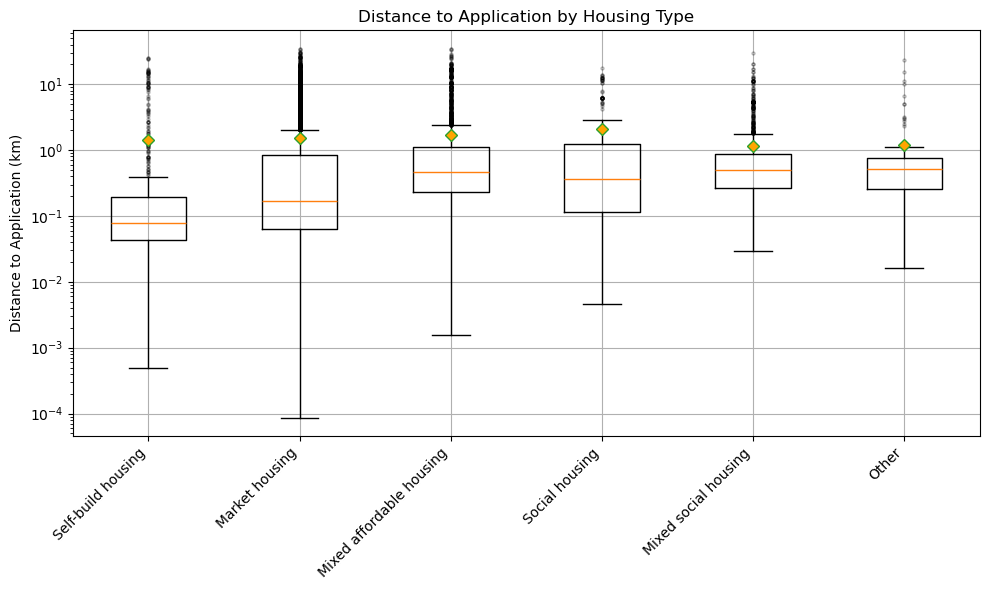

In [32]:
# boxplot of distnace by housing type
plt.figure(figsize=(10, 6))
data_to_plot = []
x_labels = []
housing_types = df['housing_type'].dropna().unique()
for ht in housing_types:
    distances = df[df['housing_type'] == ht]['distance_to_application_km'].dropna()
    if len(distances) > 0:
        data_to_plot.append(distances)
        x_labels.append(ht)
plt.boxplot(data_to_plot, labels=x_labels, vert=True, flierprops=dict(marker='o', markersize=2, alpha=0.3), showmeans=True,
            meanprops=dict(marker='D', markerfacecolor='orange'))
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title('Distance to Application by Housing Type')
plt.ylabel('Distance to Application (km)')
plt.grid(True)
plt.tight_layout()
plt.show()

### What's happening within 100m (=0.1km) of the planning applications?

In [33]:
threshold = 0.1  # km
# percent below 0.1km by housing type
percent_below_threshold = df[df['distance_to_application_km'] < threshold].groupby('housing_type').size() / df.groupby('housing_type').size() * 100
percent_below_threshold

housing_type
Market housing              24.989282
Mixed affordable housing     7.060391
Mixed social housing         1.891892
Other                        8.520179
Self-build housing          25.658454
Social housing               3.834808
dtype: float64

In [34]:
# percent below 0.1km by topic
topic_below_threshold = {}
for topic, count in topic_counts.items():
    distances = df[df['topic_number_updated'].apply(lambda x: topic in x)]['distance_to_application_km']
    if len(distances) > 0:
        count_below = (distances < threshold).sum()
        percent_below = (count_below / len(distances)) * 100
        topic_label = filtered_topic_dict.get(topic, f'Topic {topic}')
        topic_below_threshold[topic_label] = percent_below

In [35]:
topic_below_threshold

{'parking traffic car already': 23.28864634001661,
 'trees garden green space': 23.198744471393923,
 'character design out of': 19.935460738615994,
 'height scale buildings tall': 18.402574605032182,
 'noise disruption pollution will': 24.5126993502658,
 'light sunlight daylight loss': 25.600505689001263,
 'density overdevelopment overcrowding dense': 17.38293778062861,
 'amenity impact on of': 18.938401048492793,
 'conservation heritage listed area': 14.802867383512543,
 'family bedroom housing social': 25.165562913907287,
 'privacy overlooking loss windows': 28.436018957345972,
 'congested parking already traffic': 19.364024679639297,
 'safety dangerous traffic fire': 26.23318385650224,
 'bin refuse storage bins': 24.818049490538574,
 'height light privacy of': 23.761375126390295,
 'environment wildlife biodiversity local': 16.12576064908722,
 'water drainage flooding flood': 26.265822784810126,
 'view from the my': 19.919246298788696,
 'consultation engagement process been': 16.6892

In [36]:
# ranked topic_below_threshold
ranked_topic_below_threshold = dict(sorted(topic_below_threshold.items(), key=lambda item: item[1], reverse=True))
ranked_topic_below_threshold

{'privacy overlooking loss windows': 28.436018957345972,
 'water drainage flooding flood': 26.265822784810126,
 'safety dangerous traffic fire': 26.23318385650224,
 'light sunlight daylight loss': 25.600505689001263,
 'family bedroom housing social': 25.165562913907287,
 'bin refuse storage bins': 24.818049490538574,
 'noise disruption pollution will': 24.5126993502658,
 'height light privacy of': 23.761375126390295,
 'parking traffic car already': 23.28864634001661,
 'trees garden green space': 23.198744471393923,
 'disabled parking elderly accessible': 23.036649214659686,
 'rent dwelling bed viability': 22.413793103448278,
 'impact parking on amenity': 20.558002936857562,
 'dust pollution air noise': 20.209580838323355,
 'parking character is traffic': 20.107719928186714,
 'character design out of': 19.935460738615994,
 'view from the my': 19.919246298788696,
 'congested parking already traffic': 19.364024679639297,
 'amenity impact on of': 18.938401048492793,
 'height scale building